# 1. Perkenalan Dataset

**Mahasiswa:** Muhammad Yusuf (APC005D6Y0216)

**Dataset:** Rice (Cammeo & Osmancik) — UCI ML Repository id 545

**Sumber:** https://archive.ics.uci.edu/dataset/545/rice+cammeo+and+osmancik

**Deskripsi:** Dua varietas beras Turki yang diklasifikasikan berdasarkan 7 fitur morfologi hasil pencitraan (area, perimeter, panjang, lebar, eccentricity, convex_area, extent). Total 3810 sampel biner (Cammeo vs Osmancik). Cocok untuk klasifikasi biner dengan akurasi tinggi.

**Alasan pemilihan:**
- Rekomendasi default PRD MSML (UCI 545, akurasi ~0.93).
- Biner, mudah diinterpretasi.
- Cocok untuk studi kasus MLOps end-to-end.

# 2. Import Library

In [1]:
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)
print('library ready')

library ready


# 3. Memuat Dataset

In [2]:
RAW = Path('../Membangun_model/rice_raw.csv')
df = pd.read_csv(RAW)
print(df.shape)
df.head()

(3810, 8)


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231,525.578979,229.749878,85.093788,0.928882,15617,0.572896,Cammeo
1,14656,494.311005,206.020065,91.730972,0.895405,15072,0.615436,Cammeo
2,14634,501.122009,214.106781,87.768288,0.912118,14954,0.693259,Cammeo
3,13176,458.342987,193.337387,87.448395,0.891861,13368,0.640669,Cammeo
4,14688,507.166992,211.743378,89.312454,0.906691,15262,0.646024,Cammeo


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               3810 non-null   int64  
 1   Perimeter          3810 non-null   float64
 2   Major_Axis_Length  3810 non-null   float64
 3   Minor_Axis_Length  3810 non-null   float64
 4   Eccentricity       3810 non-null   float64
 5   Convex_Area        3810 non-null   int64  
 6   Extent             3810 non-null   float64
 7   Class              3810 non-null   object 
dtypes: float64(5), int64(2), object(1)
memory usage: 238.3+ KB


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
count,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000
mean,12667.727559,454.239180,188.776222,86.313750,0.886871,12952.496850,0.661934
std,1732.367706,35.597081,17.448679,5.729817,0.020818,1776.972042,0.077239
min,7551.000000,359.100006,145.264465,59.532406,0.777233,7723.000000,0.497413
25%,11370.500000,426.144752,174.353855,82.731695,0.872402,11626.250000,0.598862
50%,12421.500000,448.852493,185.810059,86.434647,0.889050,12706.500000,0.645361
75%,13950.000000,483.683746,203.550438,90.143677,0.902588,14284.000000,0.726562
max,18913.000000,548.445984,239.010498,107.542450,0.948007,19099.000000,0.861050


# 4. Exploratory Data Analysis (EDA)

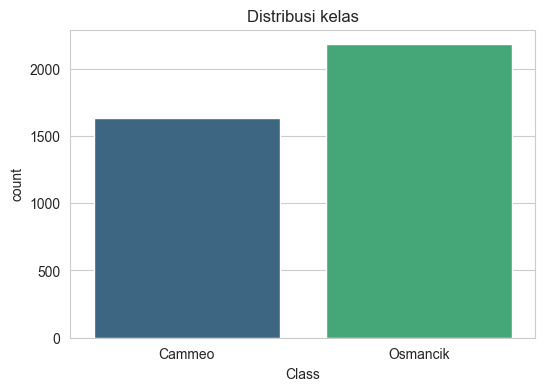

In [4]:
# 4a. Distribusi kelas
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(x='Class', data=df, hue='Class', palette='viridis', legend=False)
ax.set_title('Distribusi kelas')
plt.show()

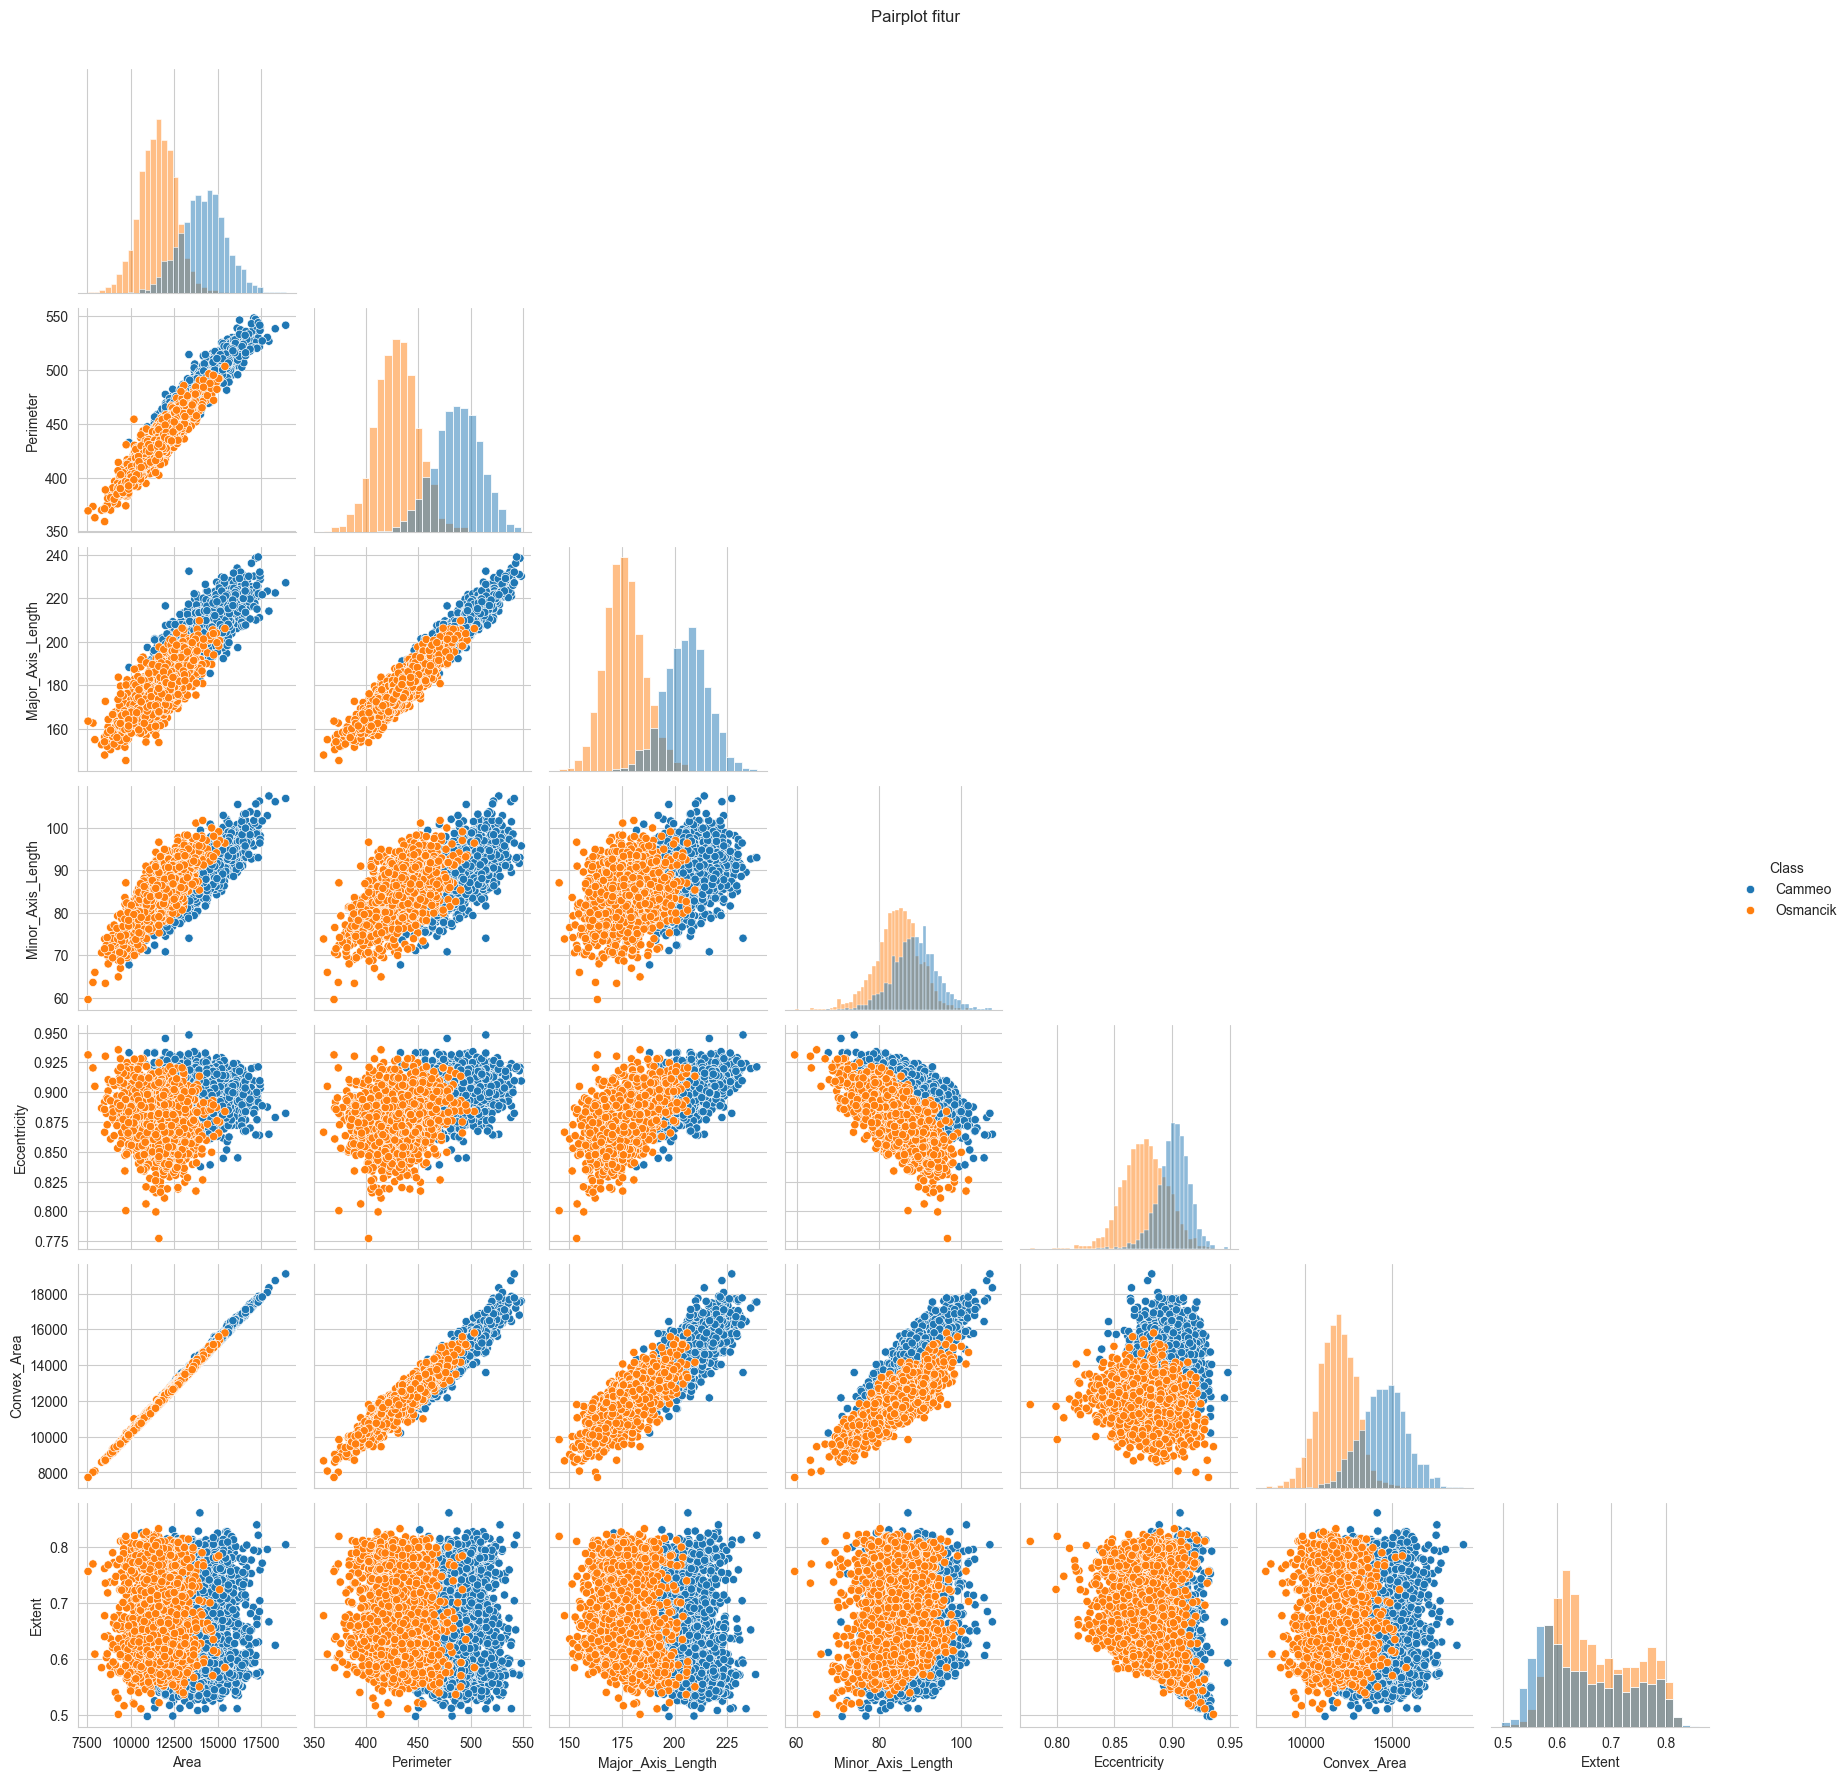

In [5]:
# 4b. Pairplot fitur numerik (ringkas)
sns.pairplot(df, hue='Class', diag_kind='hist', corner=True)
plt.suptitle('Pairplot fitur', y=1.02)
plt.show()

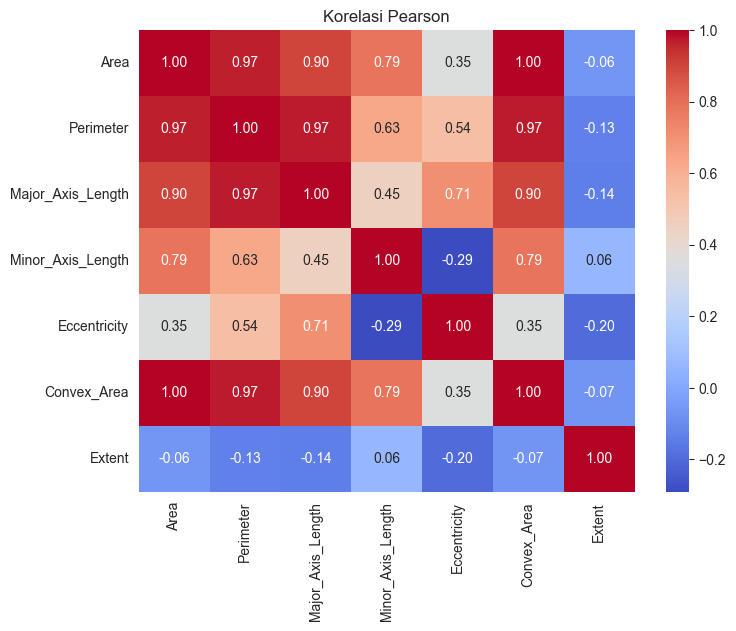

In [6]:
# 4c. Korelasi fitur numerik
numeric = df.select_dtypes(include=np.number)
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(numeric.corr(), annot=True, cmap='coolwarm', ax=ax, fmt='.2f')
ax.set_title('Korelasi Pearson')
plt.show()

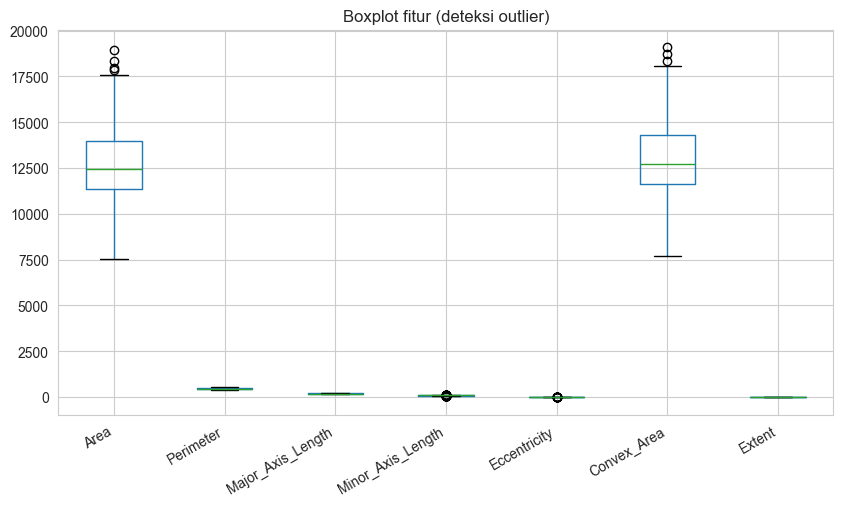

In [7]:
# 4d. Boxplot outlier screening
fig, ax = plt.subplots(figsize=(10,5))
df.drop(columns=['Class']).boxplot(ax=ax)
ax.set_title('Boxplot fitur (deteksi outlier)')
plt.xticks(rotation=30, ha='right')
plt.show()

# 5. Data Preprocessing

In [8]:
# Tahapan preprocessing mengikuti automate_rice.py (idempotent):
# dedupe/dropna -> encode label -> split -> scale -> simpan ke disk.
target = 'Class'
features = [c for c in df.columns if c != target]

df_clean = df.dropna().drop_duplicates().reset_index(drop=True)
le = LabelEncoder()
y = le.fit_transform(df_clean[target])
X = df_clean[features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10, stratify=y
)
sc = StandardScaler()
X_train_s = pd.DataFrame(sc.fit_transform(X_train), columns=features)
X_test_s = pd.DataFrame(sc.transform(X_test), columns=features)

print('train', X_train_s.shape, 'test', X_test_s.shape)
print('classes:', le.classes_)

# Simpan dataset hasil preprocessing + encoder/scaler ke rice_preprocessing/
OUT_DIR = Path('../Membangun_model/rice_preprocessing')
OUT_DIR.mkdir(parents=True, exist_ok=True)

train_out = X_train_s.copy()
train_out[target] = le.inverse_transform(y_train)
test_out = X_test_s.copy()
test_out[target] = le.inverse_transform(y_test)

train_out.to_csv(OUT_DIR / 'train.csv', index=False)
test_out.to_csv(OUT_DIR / 'test.csv', index=False)
joblib.dump(sc, OUT_DIR / 'scaler.joblib')
joblib.dump(le, OUT_DIR / 'label_encoder.joblib')

print(f'Preprocessed dataset saved -> {OUT_DIR.resolve()}')
print(os.listdir(OUT_DIR))

train (3048, 7) test (762, 7)
classes: ['Cammeo' 'Osmancik']
Preprocessed dataset saved -> C:\Users\Yusuf\coding\MSLM - SUBMISSION\SMSML_Yusuf\Membangun_model\rice_preprocessing
['eda_boxplots.png', 'eda_class_distribution.png', 'eda_correlation.png', 'eda_feature_histograms.png', 'label_encoder.joblib', 'scaler.joblib', 'test.csv', 'train.csv']


# 6. Kesimpulan EDA

- Distribusi kelas relatif seimbang (Cammeo & Osmancik, ~1630 + ~2180).
- Fitur area, perimeter, panjang, lebar berkorelasi kuat (multicollinearity).
- Outlier terlihat pada fitur `Extent`; namun model tree-based dapat menanganinya.
- Data sudah bersih (tanpa missing/duplicate setelah dedupe).
- Lanjut ke tahap modelling di folder `Membangun_model/modelling.py`.